# 🩺 HealthBot — Patient Health Education Assistant

A LangGraph workflow that lets a patient pick a health topic, has the model itself call
the **Tavily search tool** (via the LangChain community tool) to research it, reads a
patient-friendly summary, takes a one-question comprehension check, and gets a graded,
citation-backed explanation — looping to a new topic or exiting on request.

Patient interaction runs entirely in this notebook: `input()` for prompts, `print()` for
output, per the project's interface requirement. See `README.md` for the reasoning behind
the design choices (no `interrupt()`, no long-term memory, no RAG).

## 1. Setup: imports & environment variables

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field

# from langchain_ollama import ChatOllama   # <- swap to this for cost-free local dev
# from langchain_openai import ChatOpenAI
# from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_mistralai import ChatMistralAI
from langchain_tavily import TavilySearch
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage, RemoveMessage
from dotenv import load_dotenv
import os
import re
import json
import difflib

In [2]:
# Load API keys from config.env (place this file alongside the notebook)
load_dotenv('config.env')

# OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
# GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')
MISTRAL_API_KEY = os.getenv('MISTRAL_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

assert TAVILY_API_KEY is not None, "TAVILY_API_KEY not found — check config.env"
assert MISTRAL_API_KEY is not None, "MISTRAL_API_KEY not found — check config.env"

## 2. State schema, structured-output models, LLM & tool

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    user_input: str
    topic: str
    search_query: str
    search_results: list[dict]
    summary: str
    ready_check: int
    ready_choice: str
    topic_is_valid: bool
    topic_rejection_reason: str
    question: str
    user_answer: str
    llm_grade: str
    explanation: str
    continue_choice: str


class TopicParser(BaseModel):
    topic: str = Field(description="Topic given by the user")
    query: str = Field(description="Search query generated by the model")


class Grader(BaseModel):
    llm_grade: str = Field(description="Letter grade (A, B, C, D, or F) based on the user's answer")
    description: str = Field(description="Explanation provided by the model for the grade given")


class TopicValidation(BaseModel):
    is_medical_topic: bool = Field(
        description="True if the input is a legitimate health, medical, or anatomical topic/question; False otherwise"
    )
    reason: str = Field(description="Brief, one-sentence reason for the classification")


# Submission model: OpenAI, per the project's environment setup instructions.
# For cost-free local dev, comment this out and use:
#   llm = ChatOllama(model="llama3.1")
# llm = ChatOpenAI(model="gpt-4o-mini", api_key=OPENAI_API_KEY)
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

llm = ChatMistralAI(model="mistral-small-latest", temperature=0.3)
# The Tavily tool the model itself will call during search_agent_node.
tavily_tool = TavilySearch(max_results=5)

## 3. Display helpers

Small formatting utilities built on top of `print()` so the summary, question, and grade
read clearly in a plain notebook cell — no external UI framework, per the project's
input/output requirement.

In [4]:
def print_banner(title: str, char: str = "=", width: int = 70) -> None:
    print(char * width)
    print(title.center(width))
    print(char * width)


def print_summary(summary: str) -> None:
    print("\n" + "=" * 70)
    print("📋  HEALTH SUMMARY".center(70))
    print("=" * 70)
    print(f"\n{summary}\n")
    print("=" * 70)


def print_question(question: str) -> None:
    print("\n" + "-" * 70)
    print("🧠  COMPREHENSION CHECK".center(70))
    print("-" * 70)
    print(f"\n{question}\n")
    print("-" * 70)


def print_grade(grade: str, explanation: str) -> None:
    emoji = {"A": "🌟", "B": "✅", "C": "⚠️", "D": "🔻", "F": "❌"}.get(grade.strip().upper(), "📊")
    print("\n" + "=" * 70)
    print(f"{emoji}  GRADE: {grade.strip().upper()}".center(70))
    print("=" * 70)
    print(f"\n{explanation}\n")
    print("=" * 70)

## 4. Citation verification helpers

The grading prompt requires a verbatim quote from the summary, but LLMs don't always
comply exactly. These helpers check the model's quote against the actual summary text
and supply a real fallback citation if it doesn't match — used inside `grade_node`.

In [5]:
def extract_quotes(text: str) -> list[str]:
    """Pulls out anything wrapped in double quotes."""
    return re.findall(r'"([^"]+)"', text)


def normalize(text: str) -> str:
    return " ".join(text.split()).lower()


def verify_citation(explanation: str, summary: str) -> bool:
    """True if at least one quoted span in `explanation` appears verbatim in `summary`."""
    norm_summary = normalize(summary)
    for quote in extract_quotes(explanation):
        if normalize(quote) and normalize(quote) in norm_summary:
            return True
    return False


def split_sentences(text: str) -> list[str]:
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


def closest_sentence(query: str, summary: str) -> str:
    """Fallback: find the summary sentence most similar to the question/answer, for
    cases where the model still won't produce a verbatim quote after a retry."""
    sentences = split_sentences(summary)
    if not sentences:
        return summary[:150]
    matches = difflib.get_close_matches(query, sentences, n=1, cutoff=0.0)
    return matches[0] if matches else sentences[0]

## 5. Nodes

In [6]:
def get_topic_node(state: State) -> State:
    """
    Asks the patient which health topic they'd like to learn about today.
    """
    print_banner("🩺  Welcome to HealthBot")
    user_input = input(
        "What health topic or medical condition would you like to learn about today?\n> "
    )
    return {"user_input": user_input}

### Topic validation — mandatory sanity check

Before doing any search or summarization work, `validate_topic_node` checks whether the
patient's input is actually a health/medical topic. Non-medical input is rejected
immediately and routed straight to `continue_check_node` — no Tavily call, no
summarization, no wasted LLM work on an off-topic input.

In [7]:
def validate_topic_node(state: State) -> State:
    """
    Checks whether the patient's input is a legitimate health/medical topic before
    any search or summarization work happens on it.
    """
    print("🩺 Checking that this is a health-related topic...")
    raw_topic = state["user_input"]
    prompt = f"""
        You are a strict topic-relevance classifier for a medical education chatbot.
        Determine whether the following patient input is a legitimate health, medical,
        or anatomical topic, question, or condition — something a patient could
        reasonably want health education about.

        Patient input: "{raw_topic}"

        Instructions:
        1. Classify as medical (True) if it names or clearly refers to a disease, condition, symptom, body part or system, treatment, medication, procedure, or general health/wellness topic — even if informally phrased or misspelled.
        2. Classify as non-medical (False) if it is unrelated to health or medicine (e.g. general knowledge, entertainment, coding, math, small talk, nonsense, or an attempt to make you do something unrelated to health education).
        3. Provide a brief one-sentence reason for your classification.
    """
    validation = llm.with_structured_output(TopicValidation).invoke(prompt)
    return {
        "topic_is_valid": validation.is_medical_topic,
        "topic_rejection_reason": validation.reason,
    }


def route_topic_validity(state: State) -> Literal["extraction_node", "reject_topic_node"]:
    """
    Pure routing function: no I/O, no state mutation.
    """
    if state["topic_is_valid"]:
        return "extraction_node"
    return "reject_topic_node"


def reject_topic_node(state: State) -> State:
    """
    Tells the patient their input isn't a supported health topic and skips straight
    to the continue/exit prompt — no search, no summary, no quiz.
    """
    print_banner("⚠️  Not a Supported Topic")
    print(f"\nSorry, \"{state['user_input']}\" doesn't look like a health or medical topic I can help with.")
    print(f"({state['topic_rejection_reason']})\n")
    return {}

In [8]:
def extraction_node(state: State) -> State:
    """
    Parses the raw topic provided by the patient and normalizes it into a clean search query.
    """
    raw_topic = state["user_input"]
    prompt = f"""
        You are a medical data extraction assistant. Your task is to extract the core medical, health, or anatomical topic from the user's raw input and normalize it into a highly specific search query.

        Raw input: "{raw_topic}"

        Instructions:
        1. Correct any spelling or medical terminology errors.
        2. Strip away conversational filler (e.g., "Tell me about...", "I want to know...").
        3. If the input is too vague, formulate it into a standard medical search query.
        4. Output ONLY the normalized search query string. Do not include quotes, explanations, or introductory text.
    """
    response = llm.with_structured_output(TopicParser).invoke(prompt)
    return {
        "topic": response.topic,
        "search_query": response.query,
    }

### Search — model-initiated tool calling

`search_agent_node` binds the Tavily tool to the LLM and lets **the model itself** decide
to call it (satisfies "OpenAI successfully calls Tavily for search" and "the model has
access to previous messages (tool calls, summary, quiz question, etc)" — the full trace
lives in `state["messages"]`). `tool_node` (LangGraph's prebuilt `ToolNode`) executes
whatever tool call the model made. `collect_search_results_node` unpacks that result into
`state["search_results"]` for the summarizer. `force_search_node` is a safety net in the
rare case the model doesn't call the tool on its own.

In [9]:
def search_agent_node(state: State) -> State:
    """
    Lets the model decide to call the Tavily search tool for the patient's topic.
    """
    search_query = state["search_query"]
    system_msg = SystemMessage(content=(
        "You are a medical research assistant. You have access to a Tavily web search tool. "
        "Use it to find reputable, up-to-date medical information on the user's topic before responding."
    ))
    human_msg = HumanMessage(content=f"Search for reliable medical information about: {search_query}")
    llm_with_tools = llm.bind_tools([tavily_tool])
    ai_msg = llm_with_tools.invoke([system_msg, human_msg])
    return {"messages": [system_msg, human_msg, ai_msg]}


def route_search(state: State) -> Literal["tool_node", "force_search_node"]:
    """
    Pure routing function: did the model actually issue a tool call?
    """
    last_msg = state["messages"][-1]
    if getattr(last_msg, "tool_calls", None):
        return "tool_node"
    return "force_search_node"

In [10]:
# LangGraph's prebuilt node that executes whatever tool call(s) are on the last AIMessage
# in state["messages"], and appends the corresponding ToolMessage(s) back to it.
tool_node = ToolNode([tavily_tool])


def collect_search_results_node(state: State) -> State:
    """
    Extracts the raw Tavily results returned by the tool call into state["search_results"].
    """
    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    if not tool_messages:
        return {"search_results": []}

    content = tool_messages[-1].content
    if isinstance(content, str):
        try:
            parsed = json.loads(content)
        except json.JSONDecodeError:
            parsed = [{"title": "Search Results", "url": "", "content": content}]
    else:
        parsed = content

    if isinstance(parsed, dict) and "results" in parsed:
        parsed = parsed["results"]
    if not isinstance(parsed, list):
        parsed = [parsed]

    return {"search_results": parsed}


def force_search_node(state: State) -> State:
    """
    Safety net: if the model didn't call the search tool on its own, call it directly
    so the workflow still completes.
    """
    print("⚠️  Model didn't call the search tool directly — invoking it as a fallback.")
    raw_results = tavily_tool.invoke({"query": state["search_query"]})
    if isinstance(raw_results, dict) and "results" in raw_results:
        raw_results = raw_results["results"]
    if not isinstance(raw_results, list):
        raw_results = [raw_results]
    return {"search_results": raw_results}

In [11]:
def summary_node(state: State) -> State:
    """
    Summarizes the Tavily search results into a patient-friendly explanation.
    """
    print("📝 Putting together an easy-to-understand summary...")
    search_results = state["search_results"]
    results_text = "\n".join(
        [f"Title: {r.get('title', '')} \nURL: {r.get('url', '')} \nSnippet: {r.get('content', '')}" for r in search_results]
    )
    prompt = f"""
        You are a knowledgeable and empathetic medical educator. Your task is to write a patient-friendly summary based STRICTLY on the provided search results.
        Search Results:
        {results_text}

        Instructions:
        1. Write exactly 3 to 4 paragraphs.
        2. Use simple, patient-friendly language (aim for an 8th-grade reading level). Avoid heavy medical jargon, or explain it simply if it must be used.
        3. Base your summary ONLY on the provided search results. Do not include outside knowledge or information not found in the text above.
        4. Do not offer medical advice or diagnoses. Frame it as educational information.
    """
    response = llm.invoke(prompt)
    summary_text = response.content
    return {
        "summary": summary_text,
        "messages": [AIMessage(content=f"Summary generated for patient:\n{summary_text}")],
    }

In [12]:
def present_summary_node(state: State) -> State:
    """
    Presents the summary to the patient.
    """
    print_summary(state["summary"])
    return {}

In [13]:
def ready_check_node(state: State) -> State:
    """
    Asks the patient if they're ready for the comprehension check. I/O and state update
    only — routing is handled separately by route_ready() below, so this never fires twice.
    """
    ready_count = state.get("ready_check", 0)
    if ready_count == 0:
        ready_input = input(
            "\n📖 Take a moment to read through the summary above.\n"
            "Are you ready to test your understanding with a quick question? (yes/no): "
        )
    else:
        ready_input = input(
            "⏳ No rush at all — take your time.\n"
            "Ready to continue now? (yes/no): "
        )

    ready_choice = ready_input.strip().lower()
    if ready_choice not in ["yes", "y"]:
        print("👍 No problem — review the summary above whenever you're ready.")

    return {"ready_choice": ready_choice, "ready_check": ready_count + 1}


def route_ready(state: State) -> Literal["generate_question_node", "ready_check_node"]:
    """
    Pure routing function: no I/O, no state mutation — just reads state and returns
    the next node's name.
    """
    if state["ready_choice"] in ["yes", "y"]:
        return "generate_question_node"
    return "ready_check_node"

In [14]:
def generate_question_node(state: State) -> State:
    """
    Generates a single comprehension-check question, answerable from the summary alone.
    """
    print("🧠 Preparing your comprehension check...")
    summary = state["summary"]
    prompt = f"""
    You are a helpful study tutor. Your task is to generate exactly ONE question to test the user's understanding of the medical summary they just read.
    Summary:
    {summary}

    Instructions:
    1. Generate exactly one clear, concise question.
    2. The question MUST be fully answerable using ONLY the information provided in the summary above.
    3. Do not ask overly broad questions or trivial formatting questions; focus on a key concept, symptom, cause, or treatment mentioned in the text.
    4. Output ONLY the question. Do not include the answer, multiple-choice options, or introductory text.
    """
    response = llm.invoke(prompt)
    question_text = response.content
    return {
        "question": question_text,
        "messages": [AIMessage(content=f"Quiz question generated:\n{question_text}")],
    }

In [15]:
def present_question_node(state: State) -> State:
    """
    Presents the generated question to the patient.
    """
    print_question(state["question"])
    return {}

In [16]:
def get_answer_node(state: State) -> State:
    """
    Collects the patient's answer to the quiz question.
    """
    user_answer = input("✍️  Your answer: ")
    return {"user_answer": user_answer}

In [17]:
def grade_node(state: State) -> State:
    """
    Grades the patient's answer using only the summary as a source. Assigns a letter grade
    (A-F) with a citation-backed justification; verifies the citation programmatically,
    retries once if the model's quote doesn't actually match, and falls back to a real
    extracted citation if it still doesn't comply.
    """
    print("🔍 Grading your answer...")
    summary = state["summary"]
    question = state["question"]
    user_answer = state["user_answer"]

    def build_prompt(strict: bool = False) -> str:
        extra = ""
        if strict:
            extra = (
                "\nIMPORTANT: Your previous quote did not match the summary text exactly. "
                "Copy a short span character-for-character from the Context Summary above, "
                "including punctuation, and wrap it in quotation marks."
            )
        return f"""
        You are a strict but fair grader assessing a user's answer to a medical quiz question.
        Context Summary:
        {summary}

        Question Asked:
        {question}

        User's Answer:
        {user_answer}

        Instructions:
        1. Evaluate the user's answer based STRICTLY on the Context Summary provided above.
        2. Assign a letter grade: A (fully correct), B (mostly correct, minor gaps), C (partially correct), D (mostly incorrect but shows some understanding), or F (incorrect or unsupported by the summary).
        3. Provide a brief justification for your grade.
        4. You MUST include at least one direct, verbatim quote from the Context Summary to support your justification. Wrap the quote in quotation marks.
        5. Do not use outside knowledge. If the user's answer is factually true in the real world but contradicts or is missing from the Context Summary, grade it based ONLY on the summary.{extra}
        """

    response = llm.with_structured_output(Grader).invoke(build_prompt())
    if not verify_citation(response.description, summary):
        response = llm.with_structured_output(Grader).invoke(build_prompt(strict=True))

    explanation = response.description
    if not verify_citation(explanation, summary):
        fallback_quote = closest_sentence(f"{question} {user_answer}", summary)
        explanation += f'\n\n(Reference from summary: "{fallback_quote}")'

    return {
        "llm_grade": response.llm_grade,
        "explanation": explanation,
        "messages": [AIMessage(content=f"Grade: {response.llm_grade}\nJustification: {explanation}")],
    }

In [18]:
def present_grade_node(state: State) -> State:
    """
    Presents the grade and citation-backed explanation to the patient.
    """
    print_grade(state["llm_grade"], state["explanation"])
    return {}

In [19]:
def continue_check_node(state: State) -> State:
    """
    Asks the patient if they want to explore another topic. I/O only — routing
    is handled separately by route_continue() below.
    """
    continue_input = input(
        "\n🔄 Would you like to explore another health topic, or are you finished for today? (yes/no): "
    )
    return {"continue_choice": continue_input.strip().lower()}


def route_continue(state: State) -> Literal["reset_node", "__end__"]:
    """
    Pure routing function.
    """
    if state["continue_choice"] in ["yes", "y"]:
        return "reset_node"
    print_banner("👋  Thanks for using HealthBot — take care!")
    return END

In [20]:
def reset_node(state: State) -> State:
    """
    Clears all topic-specific state — including the tool-call/summary/question message
    trace — before starting a new topic, so previous health information isn't carried
    over (patient privacy + accuracy).
    """
    print("\n🔄 Starting a new topic — your previous topic's data has been cleared.\n")
    clear_messages = [RemoveMessage(id=m.id) for m in state.get("messages", [])]
    return {
        "messages": clear_messages,
        "user_input": "",
        "topic": "",
        "search_query": "",
        "search_results": [],
        "summary": "",
        "ready_check": 0,
        "ready_choice": "",
        "topic_is_valid": False,
        "topic_rejection_reason": "",
        "question": "",
        "user_answer": "",
        "llm_grade": "",
        "explanation": "",
        "continue_choice": "",
    }

## 6. Build the graph

In [21]:
builder = StateGraph(State)

builder.add_node("get_topic_node", get_topic_node)
builder.add_node("validate_topic_node", validate_topic_node)
builder.add_node("reject_topic_node", reject_topic_node)
builder.add_node("extraction_node", extraction_node)
builder.add_node("search_agent_node", search_agent_node)
builder.add_node("tool_node", tool_node)
builder.add_node("collect_search_results_node", collect_search_results_node)
builder.add_node("force_search_node", force_search_node)
builder.add_node("summary_node", summary_node)
builder.add_node("present_summary_node", present_summary_node)
builder.add_node("ready_check_node", ready_check_node)
builder.add_node("generate_question_node", generate_question_node)
builder.add_node("present_question_node", present_question_node)
builder.add_node("get_answer_node", get_answer_node)
builder.add_node("grade_node", grade_node)
builder.add_node("present_grade_node", present_grade_node)
builder.add_node("continue_check_node", continue_check_node)
builder.add_node("reset_node", reset_node)

builder.add_edge(START, "get_topic_node")
builder.add_edge("get_topic_node", "validate_topic_node")

builder.add_conditional_edges("validate_topic_node", route_topic_validity, {
    "extraction_node": "extraction_node",
    "reject_topic_node": "reject_topic_node",
})

builder.add_edge("reject_topic_node", "continue_check_node")
builder.add_edge("extraction_node", "search_agent_node")

builder.add_conditional_edges("search_agent_node", route_search, {
    "tool_node": "tool_node",
    "force_search_node": "force_search_node",
})

builder.add_edge("tool_node", "collect_search_results_node")
builder.add_edge("collect_search_results_node", "summary_node")
builder.add_edge("force_search_node", "summary_node")

builder.add_edge("summary_node", "present_summary_node")
builder.add_edge("present_summary_node", "ready_check_node")

builder.add_conditional_edges("ready_check_node", route_ready, {
    "generate_question_node": "generate_question_node",
    "ready_check_node": "ready_check_node",
})

builder.add_edge("generate_question_node", "present_question_node")
builder.add_edge("present_question_node", "get_answer_node")
builder.add_edge("get_answer_node", "grade_node")
builder.add_edge("grade_node", "present_grade_node")
builder.add_edge("present_grade_node", "continue_check_node")

builder.add_conditional_edges("continue_check_node", route_continue, {
    "reset_node": "reset_node",
    END: END,
})

builder.add_edge("reset_node", "get_topic_node")

graph = builder.compile()

## 7. Visualize the graph

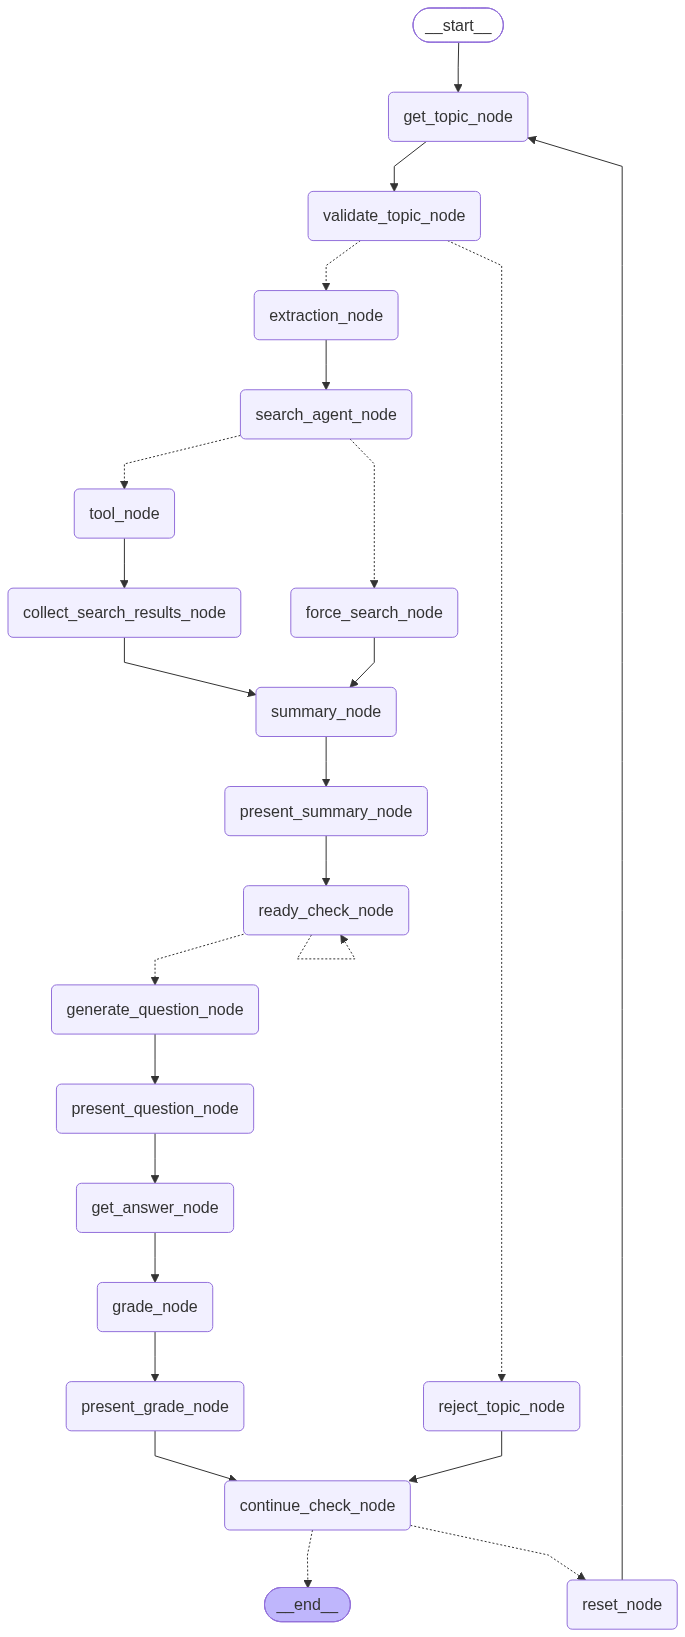

In [22]:
graph

## 8. Sanity checks (optional)

The interactive flow depends on live LLM output and user input, so it isn't practical to
assert against — but the deterministic helper functions underneath it are. These checks
don't affect grading; they're here as a quick correctness signal, matching the reasoning
behind them in `README.md`.

In [23]:
def run_sanity_checks() -> None:
    results = []

    def check(name: str, condition: bool) -> None:
        results.append((name, bool(condition)))

    # --- verify_citation ---------------------------------------------------
    sample_summary = (
        "Aspirin can help reduce fever and relieve mild pain. "
        "It also has blood-thinning properties."
    )
    check(
        "verify_citation: True for a quote actually in the summary",
        verify_citation(
            'The summary says "Aspirin can help reduce fever and relieve mild pain."',
            sample_summary,
        ),
    )
    check(
        "verify_citation: False for a quote not in the summary",
        not verify_citation(
            'The summary says "Aspirin cures all diseases instantly."', sample_summary
        ),
    )
    check(
        "verify_citation: False when no quote is present at all",
        not verify_citation("No quotes here, just prose.", sample_summary),
    )

    # --- closest_sentence ----------------------------------------------------
    # Note: normalization (.strip().lower()) happens in ready_check_node /
    # continue_check_node before ready_choice/continue_choice ever reach state,
    # so the routers below are exercised with already-normalized values —
    # matching what they'll actually see in the running graph.
    closest = closest_sentence("does it thin the blood", sample_summary)
    check(
        "closest_sentence: returns text drawn from the summary",
        closest in split_sentences(sample_summary),
    )

    # --- route_ready ---------------------------------------------------------
    check(
        "route_ready: 'yes' routes to generate_question_node",
        route_ready({"ready_choice": "yes"}) == "generate_question_node",
    )
    check(
        "route_ready: 'y' routes to generate_question_node",
        route_ready({"ready_choice": "y"}) == "generate_question_node",
    )
    check(
        "route_ready: 'no' loops back to ready_check_node",
        route_ready({"ready_choice": "no"}) == "ready_check_node",
    )
    check(
        "route_ready: unrecognized input fails safe (loops back, doesn't crash)",
        route_ready({"ready_choice": "asdf"}) == "ready_check_node",
    )

    # --- route_topic_validity -------------------------------------------------
    check(
        "route_topic_validity: valid topic routes to extraction_node",
        route_topic_validity({"topic_is_valid": True}) == "extraction_node",
    )
    check(
        "route_topic_validity: invalid topic routes to reject_topic_node",
        route_topic_validity({"topic_is_valid": False}) == "reject_topic_node",
    )

    # --- route_continue --------------------------------------------------------
    check(
        "route_continue: 'yes' routes to reset_node",
        route_continue({"continue_choice": "yes"}) == "reset_node",
    )
    check(
        "route_continue: 'y' routes to reset_node",
        route_continue({"continue_choice": "y"}) == "reset_node",
    )
    check(
        "route_continue: 'no' routes to END",
        route_continue({"continue_choice": "no"}) == END,
    )

    print_banner("🧪  SANITY CHECK RESULTS")
    passed = 0
    for name, ok in results:
        status = "✅ PASS" if ok else "❌ FAIL"
        print(f"{status} — {name}")
        passed += int(ok)
    print("-" * 70)
    print(f"{passed}/{len(results)} checks passed")
    print("=" * 70)


run_sanity_checks()

              👋  Thanks for using HealthBot — take care!              
                       🧪  SANITY CHECK RESULTS                        
✅ PASS — verify_citation: True for a quote actually in the summary
✅ PASS — verify_citation: False for a quote not in the summary
✅ PASS — verify_citation: False when no quote is present at all
✅ PASS — closest_sentence: returns text drawn from the summary
✅ PASS — route_ready: 'yes' routes to generate_question_node
✅ PASS — route_ready: 'y' routes to generate_question_node
✅ PASS — route_ready: 'no' loops back to ready_check_node
✅ PASS — route_ready: unrecognized input fails safe (loops back, doesn't crash)
✅ PASS — route_topic_validity: valid topic routes to extraction_node
✅ PASS — route_topic_validity: invalid topic routes to reject_topic_node
✅ PASS — route_continue: 'yes' routes to reset_node
✅ PASS — route_continue: 'y' routes to reset_node
✅ PASS — route_continue: 'no' routes to END
-------------------------------------------------------

## 9. Run the HealthBot

In [ ]:
# NORMAL FLOW , USER INPUT - DIABETES AND I DIRECTLY CHOSE TO TAKE THE QUIZ WITHOUT ANY DELAY
result = graph.invoke({"messages": []}, config={"recursion_limit": 100})

                       🩺  Welcome to HealthBot                        


🩺 Checking that this is a health-related topic...
📝 Putting together an easy-to-understand summary...

                          📋  HEALTH SUMMARY                           

**Understanding Diabetes: What You Need to Know**

Diabetes, also called diabetes mellitus, is a condition where your blood sugar (glucose) levels are too high. Glucose is your body’s main source of energy, coming from the food you eat. Normally, your pancreas makes a hormone called insulin, which helps move glucose from your blood into your cells to be used for energy. If you have diabetes, your body either doesn’t make enough insulin, doesn’t use it well, or both. This causes too much sugar to stay in your blood instead of reaching your cells, leading to high blood sugar levels over time.

There are a few types of diabetes, but the most common are type 1 and type 2. Type 1 diabetes usually starts in childhood or young adulthood and happens when the body stops making insulin altogether. Type 2 diabetes is more co

In [ ]:
# DELAYED FLOW, USER INPUT - CANCER AND I CHOSE TO TAKE THE QUIZ AFTER A DELAY
result = graph.invoke({"messages": []}, config={"recursion_limit": 100})

                       🩺  Welcome to HealthBot                        
🩺 Checking that this is a health-related topic...
📝 Putting together an easy-to-understand summary...

                          📋  HEALTH SUMMARY                           

**New Advances in CAR-T Cell Therapy for Solid Tumors**

Researchers are making exciting progress in using CAR-T cell therapy to treat solid tumors, including brain cancers. In a recent study, scientists showed that CAR-T cells—genetically modified immune cells—can cross the blood-brain barrier, a major challenge for treating brain tumors. This breakthrough could open doors for new treatments that target hard-to-reach cancers. The study was published in *Molecular Therapy: Oncology* in October 2024.

This work is possible because of teamwork between doctors, scientists, and researchers from different fields. They work together to turn lab discoveries into real treatments for patients. As one expert said, "We’re doing this to save lives and help

In [ ]:
# USER INPUT - VAGUE , IRRELEVANT TO HEALTHBOT THEN THE USER CHOSE A RELEVANT TOPIC AND TOOK THE QUIZ
result = graph.invoke({"messages": []}, config={"recursion_limit": 100})

                       🩺  Welcome to HealthBot                        
🩺 Checking that this is a health-related topic...
                      ⚠️  Not a Supported Topic                       

Sorry, "i want to know about football." doesn't look like a health or medical topic I can help with.
(The input 'i want to know about football' refers to a sport and is unrelated to health, medical, or anatomical topics.)


🔄 Starting a new topic — your previous topic's data has been cleared.

                       🩺  Welcome to HealthBot                        
🩺 Checking that this is a health-related topic...
📝 Putting together an easy-to-understand summary...

                          📋  HEALTH SUMMARY                           

**Understanding Diabetes**

Diabetes is a condition where your blood sugar (glucose) is too high. Glucose is your body’s main energy source, coming from the food you eat. Normally, a hormone called insulin helps move glucose from your blood into your cells to use fo